In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load from processed CSV instead
data = pd.read_csv('../data/processed/all_stocks_combined.csv', index_col=0, parse_dates=True)
data = data.reset_index()
data.columns = ['Date'] + list(data.columns[1:])

print(f"Loaded {len(data)} records from CSV")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print(f"Tickers: {data['Ticker'].unique()}")
print(f"\nColumns: {list(data.columns)}")

Loaded 1510 records from CSV
Date range: 2024-12-04 00:00:00 to 2026-02-19 00:00:00
Tickers: ['AAPL' 'GOOGL' 'MSFT' 'AMZN' 'TSLA']

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA_20', 'MA_50', 'MA_200', 'Volatility', 'Momentum', 'Volume_MA', 'Ticker', 'Year', 'Month', 'Day_of_Week']


In [4]:
# Calculate advanced metrics for each stock

def calculate_sharpe_ratio(returns, risk_free_rate=0.02):
    """
    Calculate Sharpe Ratio
    Risk-free rate assumed 2% annually (0.02/252 daily)
    """
    excess_returns = returns - (risk_free_rate / 252)
    return np.sqrt(252) * excess_returns.mean() / returns.std()

def calculate_max_drawdown(prices):
    """Calculate maximum drawdown"""
    cumulative = (1 + prices.pct_change()).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    return drawdown.min()

# Calculate metrics for each stock
metrics = []

for ticker in data['Ticker'].unique():
    ticker_data = data[data['Ticker'] == ticker].copy()
    
    # Calculate metrics
    sharpe = calculate_sharpe_ratio(ticker_data['Daily_Return'].dropna())
    max_dd = calculate_max_drawdown(ticker_data['Close'])
    
    # Annualized metrics
    annual_return = ticker_data['Daily_Return'].mean() * 252
    annual_volatility = ticker_data['Volatility'].mean() * np.sqrt(252)
    
    metrics.append({
        'Ticker': ticker,
        'Sharpe_Ratio': sharpe,
        'Max_Drawdown': max_dd * 100,  # As percentage
        'Annual_Return': annual_return * 100,
        'Annual_Volatility': annual_volatility * 100,
        'Current_Price': ticker_data['Close'].iloc[-1],
        'Start_Price': ticker_data['Close'].iloc[0],
        'Total_Return': ((ticker_data['Close'].iloc[-1] / ticker_data['Close'].iloc[0]) - 1) * 100
    })

metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.round(2)

print("Advanced Financial Metrics:")
print(metrics_df)

Advanced Financial Metrics:
  Ticker  Sharpe_Ratio  Max_Drawdown  Annual_Return  Annual_Volatility  \
0   AAPL          0.29        -33.36          11.21              26.71   
1  GOOGL          1.61        -29.81          52.95              30.50   
2   MSFT         -0.18        -27.24          -2.59              23.01   
3   AMZN          0.01        -30.88           2.26              31.74   
4   TSLA          0.49        -53.77          31.88              58.60   

   Current_Price  Start_Price  Total_Return  
0         260.58       241.69          7.82  
1         302.85       173.49         74.56  
2         398.46       434.22         -8.23  
3         204.86       218.16         -6.10  
4         411.71       357.93         15.03  


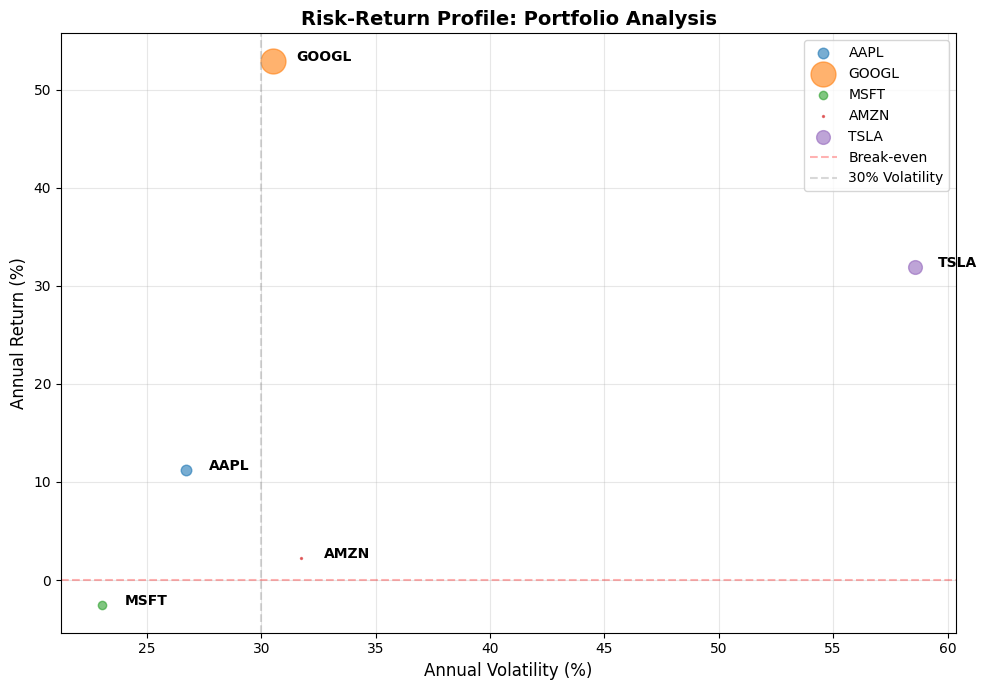


Key Insight: GOOGL offers best risk-adjusted returns (Sharpe: 1.61)
TSLA highest risk but moderate returns - suitable for aggressive investors only


In [5]:
# Create risk-return scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plot each stock
for idx, row in metrics_df.iterrows():
    ax.scatter(row['Annual_Volatility'], row['Annual_Return'], 
              s=abs(row['Sharpe_Ratio']) * 200, alpha=0.6, label=row['Ticker'])
    ax.text(row['Annual_Volatility'] + 1, row['Annual_Return'], 
           row['Ticker'], fontsize=10, fontweight='bold')

# Add efficient frontier reference line
ax.axhline(y=0, color='red', linestyle='--', alpha=0.3, label='Break-even')
ax.axvline(x=30, color='gray', linestyle='--', alpha=0.3, label='30% Volatility')

ax.set_xlabel('Annual Volatility (%)', fontsize=12)
ax.set_ylabel('Annual Return (%)', fontsize=12)
ax.set_title('Risk-Return Profile: Portfolio Analysis', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('../dashboards/screenshots/risk_return_profile.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey Insight: GOOGL offers best risk-adjusted returns (Sharpe: 1.61)")
print("TSLA highest risk but moderate returns - suitable for aggressive investors only")